<a href="https://colab.research.google.com/github/jamesriddellv/2026-Viromics-Practicals/blob/main/day3_Bioreactor_viruses_deep_dive_host_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Setup

In [1]:
# Clone the github repository to access the data and helper functions within colab.
!git clone https://github.com/jamesriddellv/2026-Viromics-Practicals.git

Cloning into '2026-Viromics-Practicals'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 128 (delta 68), reused 16 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (128/128), 8.07 MiB | 11.18 MiB/s, done.
Resolving deltas: 100% (68/68), done.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

# set fonts and ensure PDF text is editable:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'

In [3]:
# Set to the directory you uploaded the data to
import os

# Base directory for practicals
base_dir = './2026-Viromics-Practicals'

# Set data directory path
data_dir = os.path.join(base_dir, 'data')

# Verify the path exists
print("Data directory:", data_dir)
print("Files in data folder:", os.listdir(data_dir))

Data directory: ./2026-Viromics-Practicals/data
Files in data folder: ['contig_591846.gff', 'final_assignments.csv', 'contig_591846.fna', 'contig_591846_annotations.tsv', 'metaT_sample_metadata.csv', 'genomad_checkv_dramv_metadata.csv', 'cleaned_getmm_by_predicted_host.csv', 'Host_prediction_to_genome_m90.csv', 'blastgenomes_simplified.tsv', 'sample_metadata.csv', 'votu_relative_abundance.csv', '4B_contig_591846_STM_0716_E_M_E034_A_bin.10_blastn.txt', 'Prediction_Model_blast_Conv-87_simplified.csv', 'getmms_REV_5x_vOTUs_corrected_wide.tsv', 'combined_pileup.csv', 'alpha_diversity_metadata.csv', '.DS_Store', 'cleaned_getmm_by_predicted_host_additional_predictions.csv', 'genomad_checkv_metadata.csv']


# Host Prediction

Now that we know the vOTU community activity in catechin samples day 14-35 are significantly different, we want to which hosts these vOTUs infect. Given that catechin enriched for Pseudomonas_E, Clostridium, and JAGFXR01 MAGs, we'd expect changes in vOTU community activity were driven by vOTUs predicted to infect these MAGs, assuming these vOTUs and MAGs follow traditional predator-prey dynamics.

Here, we will load in vOTU abundances per-sample and virus-host predictions made with iPHoP.

[IPHoP](https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.3002083#pbio-3002083-g002) is a virus-host prediction tool that combines homology-based (BLAST, CRISPR) and alignment-free deep-learning methods. For this project, we used a custom iPHoP host database composed of 2,302 medium and high-quality MAGs recovered from these bioreactor samples and previous MAG recovery efforts in our study site. It turned out that 40% of the 900 active vOTUs had a host prediction, with 50% of those predictions being made with BLAST, suggesting a high number of active vOTUs were capable of integrating into their host genome.

We want to know (1) which vOTUs were most active in the community, and (2) who they infected. To visualize vOTU community activity by predicted hosts, we will merge iPHoP results to relative abundance by vOTU, then group by predicted host genus, summing the abundance of vOTUs predicted to infect the same host. For highly abundant vOTUs (>4% of all vOTU activity in a given set of sample replicates), we will plot them individually in a slightly different color to get a sense for how much these highly active vOTUs expressed compared to the rest of the community.

# Part 1: Who are the most active vOTUs between treatments and over time?

In [4]:
# Load metaT GeTMM relative abundance table
file_name = 'getmms_REV_5x_vOTUs_corrected_wide.tsv'
path = '/'.join([data_dir, file_name])
df = pd.read_csv(path, sep='\t')
df.head()

,vOTU,STM_0716_E_M_E002,STM_0716_E_M_E003,STM_0716_E_M_E004,STM_0716_E_M_E025,STM_0716_E_M_E027,STM_0716_E_M_E033,STM_0716_E_M_E034,STM_0716_E_M_E035,STM_0716_E_M_E050,...,STM_0716_E_M_E064,STM_0716_E_M_E070,STM_0716_E_M_E071,STM_0716_E_M_E072,STM_0716_E_M_E121,STM_0716_E_M_E122,STM_0716_E_M_E123,STM_0716_E_M_E129,STM_0716_E_M_E130,STM_0716_E_M_E131
0,contig_1000294|provirus_2_36746,0.0,0.0,0.0,72.464003,0.00000,0.000000,0.000000,0.000000,11.604841,...,0.00000,0.000000,0.000000,0.000000,71.239766,5.254664,0.000000,0.000000,0.000000,0.000000
1,contig_1000563,0.0,0.0,0.0,48.863221,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,264.821441,142.841287,409.715377,172.501055,118.109324,123.695971
2,contig_1000567,0.0,0.0,0.0,130.730865,69.63963,31.846424,72.690802,35.164220,200.725731,...,31.41151,30.464602,18.219285,21.022699,176.074381,40.904563,122.369957,53.767472,58.008758,50.326227
3,contig_1000721,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,214.109537,48.431831,...,0.00000,0.000000,22.769334,0.000000,14.917165,25.698245,0.000000,0.852605,0.000000,0.000000
4,contig_1001917,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [5]:
# Load iPHoP host prediction table

file_name = 'Host_prediction_to_genome_m90.csv'
path = '/'.join([data_dir, file_name])
iphop_df = pd.read_csv(path)
iphop_df.head()

,Virus,Host genome,Host taxonomy,Main method,Confidence score,Additional methods
0,contig_1000262,RS_GCF_900167265.1,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Cl...,iPHoP-RF,92.8,NaN
1,contig_1000294|provirus_2_36746,RS_GCF_005938625.1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,blast,92.4,iPHoP-RF;73.50
2,contig_1000294|provirus_2_36746,RS_GCF_012986595.1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,blast,92.3,iPHoP-RF;59.20
3,contig_1000294|provirus_2_36746,RS_GCF_000633255.1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,blast,92.1,iPHoP-RF;80.00
4,contig_1000294|provirus_2_36746,RS_GCF_002890915.1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,iPHoP-RF,91.8,CRISPR;58.50


Take a look at the different columns in iphop_df: this is the genome-level output file.

'Virus': The vOTU contig name.

'Host genome': The MAG accession (if iPHoP standard database) or MAG name from custom added MAGs.

'Host taxonomy': The GTDB taxonomy from GTDB-classify.

'Main method': The main prediction module from iPHoP used to make the prediction (BLAST, CRISPR, iPHoP-RandomForest, RaFAH, etc.)

'Confidence score': iPHoP's composite score of all the tools, with a false discovery rate of less than 10%.

'Additional method': The method and confidence score of any additional tools that also made a host prediction.
There is also a genus-level output file, but we are specifically interested in matching these vOTUs to specific MAGs for downstream analysis.

We will skip the data wrangling for sake of time, but if you are curious how the iphop table and relative abundance tables were merged and filtered, check the code here: https://github.com/jamesriddellv/Grantham_Bioreactor/blob/main/03-predict-hosts/scripts/06-host-prediction-EDA.py

In [6]:
# Load in the cleaned merged dataframe containing the relative abundance of vOTUs grouped per-treatment, per-timepoint, per-predicted host.
file_name = 'cleaned_getmm_by_predicted_host.csv'
path = '/'.join([data_dir, file_name])
clean_df = pd.read_csv(path)
clean_df.head()

,treatment,day,taxon_grouped,taxon_grouped_abundance,taxon_grouped_prop_abundance,color
0,catechin,7,Other,178.086001,0.013426,black
1,catechin,7,g__Clostridium,3649.791209,0.275167,#9E0B0F
2,catechin,7,g__Clostridium__contig_507316,216.432818,0.016317,#DC143C
3,catechin,7,g__Clostridium__contig_588865,474.995312,0.035811,#FF4500
4,catechin,7,g__Clostridium__contig_755337,379.058671,0.028578,#B22222


Here's a quick overview on the dataframe:
* Treatment: 'catechin' or 'unamended'
* day: The day of sampling (0, 7, 14, 21, and 35)
* taxon_grouped: The predicted host genus. MAGs <4% abundance in any single sample are grouped into "Other". vOTUs with especially high relative abundance in a single day (determined with rank abundance curve) are not grouped, and labeled with their host prediction pre-pended to the contig name, allowing us to plot them individually.
* taxon_grouped_abundance: the sum GeTMM of all vOTUs with the same genus prediction (except those especially abundant vOTUs) across all replicates.
* taxon_grouped_prop_abundance: proportion of all vOTU GeTMM relative abundance attributable to vOTUs in 'taxon_grouped' across replicates for a given treatment and day.
* color: the color to plot the values in. Especially abundant vOTUs plotted in different shades of the same color as the grouped vOTUs with the same predicted host.

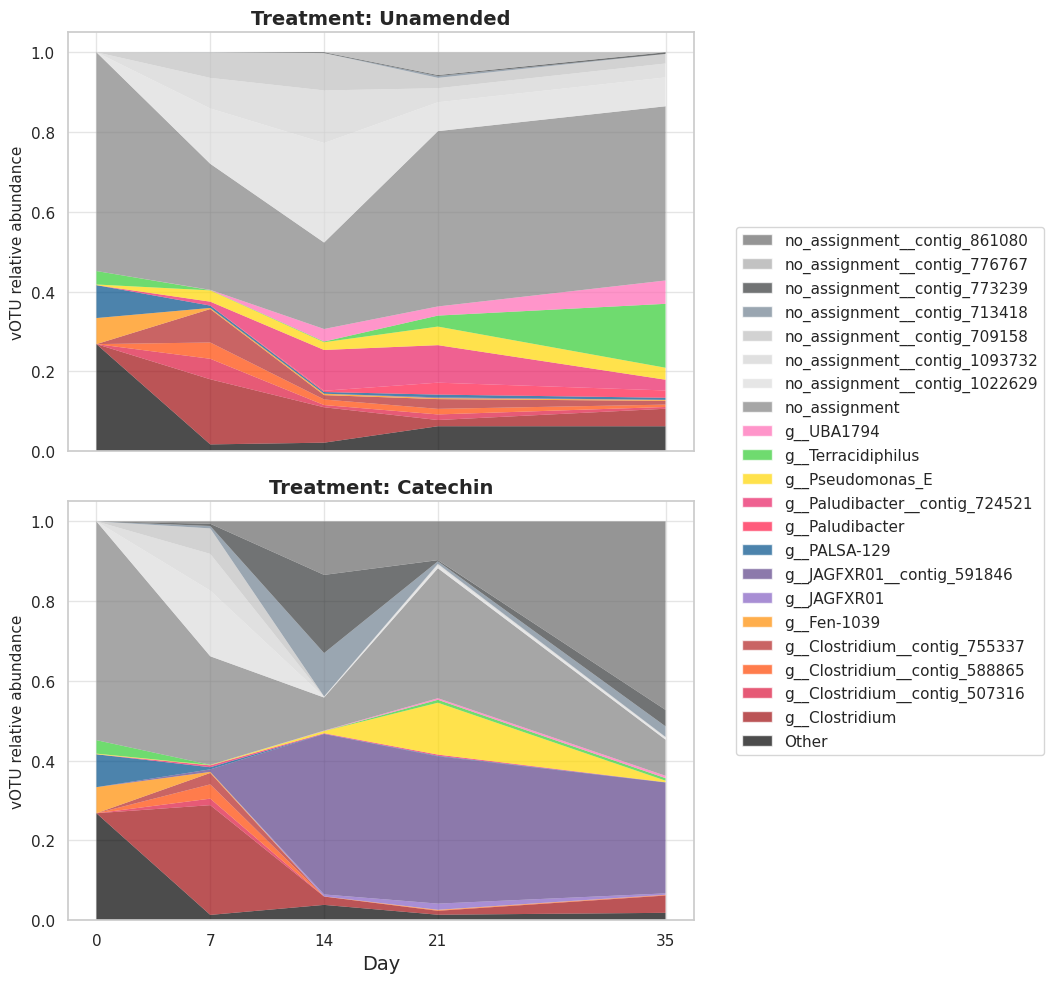

In [7]:
# Next, we will use the following function to visualize vOTU community abundance per day in each treatment.
# The graph we are going to produce is called a stacked area chart, but feel free to modify the code and visualize the data another way (stacked bar graph?) instead.
# The AI assist feature could be especially fun here to plot the data in different ways.

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# 1. Create a color mapping directly from clean_df
color_map = clean_df.drop_duplicates('taxon_grouped').set_index('taxon_grouped')['color']

# 2. Get all unique taxa across both treatments for a consistent color order & legend
all_taxa = sorted(clean_df['taxon_grouped'].dropna().unique())

# 3. Set up a 2-row, 1-column layout for plots with space on the right for the legend
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True, sharey=True)

treatments = ['unamended', 'catechin']

for ax, treatment in zip(axes, treatments):
    # Filter and pivot treatment data
    df_treatment = clean_df[clean_df['treatment'] == treatment]
    df_pivot = df_treatment.pivot(
        index='day',
        columns='taxon_grouped',
        values='taxon_grouped_prop_abundance'
    ).reindex(columns=all_taxa, fill_value=0) # Keep all taxa aligned

    # Map colors to current columns
    colors = [color_map.get(col, 'gray') for col in df_pivot.columns]

    # Plot stacked area chart
    ax.stackplot(
        df_pivot.index,
        df_pivot.T.values,
        colors=colors,
        alpha=0.7,
        edgecolor='none'
    )

    # Subplot styling
    ax.set_title(f"Treatment: {treatment.capitalize()}", fontsize=14, fontweight='bold')
    ax.set_ylabel("vOTU relative abundance", fontsize=11)
    ax.set_xticks([0, 7, 14, 21, 35])
    ax.grid(True, alpha=0.5)

axes[1].set_xlabel("Day", fontsize=14)

# 4. Build single shared legend elements
legend_elements = []
for col in all_taxa:
    label = f"{col}" if "contig" not in col else col

    patch = Patch(
        facecolor=color_map.get(col, 'gray'),
        label=label,
        alpha=0.7
    )
    legend_elements.append(patch)

# Reverse list order for legend alignment
legend_elements = legend_elements[::-1]

# 5. Attach shared legend to the side of the figure
fig.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(0.92, 0.5), # Positions legend outside the right edge
    fontsize=11,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Reserve right side space for legend
plt.show()

In [8]:
# OPTIONAL: Ask AI to visualize 'clean_df' another way (or do it yourself!)
#           Another option is to explore the relative abundance or iphop dataframes further
...

Ellipsis

## Reflection
Do these results reinforce or contradict the beta diversity results you found from day 2? Based on these results, which vOTUs (or groups of vOTUs) do you think were driving the vOTU community response to catechin days 14-35?

**\<Type your answer here\>**

# Part 3: Leveraging iPHoP predictions and virus taxonomy to make additional host predictions
You may have noticed there were a lot of 'especially abundant' vOTUs that lacked a host prediction to an active MAG. This is quite unsatisfying--more than half the community activity is still unexplained! Without knowing who these vOTUs infect, it is much more difficult to interpret the ecology.

We can fill some of this in by (1) using the "inactive MAG" host predictions from iPHoP, meaning predictions to MAGs not detected in our study. (2) After that, we'll use vConTACT3 to make some more predictions by finding taxonomic clusters with similar host labels.

We'll put these additional predictions in a second-tier category. Even if they aren't correct, we can make an educated guess as to which host taxa they likely infect.

### Part 3a: predictions to the iPHoP reference database

In [9]:
# We will first search through the original iPHoP dataframe for these highly
# abundant vOTUs and determine which hosts they were predicted to infect

abundant_no_assignment_list = [
    'contig_861080',
    'contig_776767',
    'contig_773239',
    'contig_713418',
    'contig_709158',
    'contig_1093732',
    'contig_1022629'
]

# Clean up iphop taxonomy so it's easier to see:
iphop_df[['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']] = iphop_df['Host taxonomy'].str.split(';', expand=True)

iphop_df.loc[iphop_df['Virus'].isin(abundant_no_assignment_list)][['Virus', 'Genus', 'Species', 'Main method', 'Confidence score', 'Additional methods']]

,Virus,Genus,Species,Main method,Confidence score,Additional methods
546,contig_1022629,g__Lachnoclostridium,s__Lachnoclostridium phytofermentans_A,blast,93.9,NaN
1269,contig_1093732,g__Lachnoclostridium,s__Lachnoclostridium phytofermentans_A,blast,93.9,NaN
19296,contig_776767,g__Pseudomonas_E,s__Pseudomonas_E mohnii,blast,94.1,iPHoP-RF;62.70
19297,contig_776767,g__Pseudomonas_E,s__Pseudomonas_E atacamensis,blast,92.6,iPHoP-RF;62.20


In [10]:
# Since iPHoP predictions are genome-based, we can also get a sense for how long
# these sequences were to see if that may have played a role in no prediction:
file_name = 'genomad_checkv_metadata.csv'
path = '/'.join([data_dir, file_name])
votu_metadata = pd.read_csv(path)
votu_metadata.loc[votu_metadata['vOTU'].isin(abundant_no_assignment_list)][['vOTU','length']]

,vOTU,length
334,contig_709158,89369
388,contig_713418,5172
456,contig_773239,10785
499,contig_776767,7366
558,contig_861080,5466
766,contig_1022629,48048
786,contig_1093732,70684


## Reflection:
1. How many of these unassigned contigs had an iPHoP host prediction to an iPHoP reference genome?

**\<Your response here\>**

2. Knowing that Clostridium and Pseudomonas_E were abundant in our samples, what is reasonable to conclude about who these vOTUs likely infect?

**\<Your response here\>**

3. Look up Lachnoclostridium--is it reasonable to assume these vOTUs infect a Clostridia in our study?

**\<Your response here\>**

4. Reflect on the vOTU sequence lengths--do you think this had anything to do with the lack of predictions? How does this also make you rethink our normalization scheme--are these vOTUs potentially over or underrepresented?

**\<Your response here\>**



## Part 3b: blending iphop and vcontact3 outputs to generate additional host predictions

Let's keep going! We'll now use gene-sharing networks to make a few additional predictions.

If we check thes vOTU lengths for the remaining vOTUs, we can see that they're almost all quite short. Our intuition was that these vOTUs lacked sufficient genomic context for iPHoP to make a confident host prediction.

Yet, vConTACT3 may be able to get around these limitations, Even with a few genes, vConTACT3 is capable of clustering vOTUs at fine taxonomic resolution. If we happen to find these unassigned vOTU fragments in a unique cluster of vOTUs that all have the same host prediction, it's possible the unassigned vOTU also infects similar MAGs if we assume closely related vOTUs generally infect related MAGs.

In [12]:
# Load in vConTACT3 data, isolate the unassigned vOTUs, then pull all vOTUs in the same genera and check host predictions
file_name = 'final_assignments.csv'
path = '/'.join([data_dir, file_name])
taxonomy_df = pd.read_csv(path)
taxonomy_df.head()


,Genome,GenomeName,Proteins,Reference,Size_Kb,realm_reference,realm_prediction,kingdom_reference,kingdom_prediction,phylum_reference,...,class_reference,class_prediction,order_reference,order_prediction,family_reference,family_prediction,subfamily_reference,subfamily_prediction,genus_reference,genus_prediction
0,MK064565.1,Sulfolobales Beppu rod-shaped virus 1,60.0,True,34.025,Adnaviria,Adnaviria,Zilligvirae,Zilligvirae,Taleaviricota,...,Tokiviricetes,Tokiviricetes,Ligamenvirales,Ligamenvirales,Rudiviridae,Rudiviridae,NaN,novel_subfamily_0_of_Rudiviridae,Japarudivirus,Azorudivirus|Hoswirudivirus|Icerudivirus|Itaru...
1,MN876841.1,Saccharolobus solfataricus rod-shaped virus 1,37.0,True,26.097,Adnaviria,Adnaviria,Zilligvirae,Zilligvirae,Taleaviricota,...,Tokiviricetes,Tokiviricetes,Ligamenvirales,Ligamenvirales,Rudiviridae,Rudiviridae,NaN,novel_subfamily_0_of_Rudiviridae,Hoswirudivirus,Azorudivirus|Hoswirudivirus|Icerudivirus|Itaru...
2,MN876842.1,Acidianus rod-shaped virus 3,33.0,True,23.666,Adnaviria,Adnaviria,Zilligvirae,Zilligvirae,Taleaviricota,...,Tokiviricetes,Tokiviricetes,Ligamenvirales,Ligamenvirales,Rudiviridae,Rudiviridae,NaN,novel_subfamily_0_of_Rudiviridae,Hoswirudivirus,Azorudivirus|Hoswirudivirus|Icerudivirus|Itaru...
3,MN876843.1,Metallosphaera rod-shaped virus 1,27.0,True,20.269,Adnaviria,Adnaviria,Zilligvirae,Zilligvirae,Taleaviricota,...,Tokiviricetes,Tokiviricetes,Ligamenvirales,Ligamenvirales,Rudiviridae,Rudiviridae,NaN,novel_subfamily_0_of_Rudiviridae,Hoswirudivirus,Azorudivirus|Hoswirudivirus|Icerudivirus|Itaru...
4,NC_004086.1,Sulfolobus islandicus rod-shaped virus 2,54.0,True,35.450,Adnaviria,Adnaviria,Zilligvirae,Zilligvirae,Taleaviricota,...,Tokiviricetes,Tokiviricetes,Ligamenvirales,Ligamenvirales,Rudiviridae,Rudiviridae,NaN,novel_subfamily_0_of_Rudiviridae,Icerudivirus,Azorudivirus|Hoswirudivirus|Icerudivirus|Itaru...


We will first filter for these additional unassigned vOTUs. Then, using their predicted genera, we will track backwards and see what the host predictions were for other vOTUs that share the same vOTU genus.

In [13]:
taxonomy_df.loc[taxonomy_df['Genome'].isin(abundant_no_assignment_list)]

,Genome,GenomeName,Proteins,Reference,Size_Kb,realm_reference,realm_prediction,kingdom_reference,kingdom_prediction,phylum_reference,...,class_reference,class_prediction,order_reference,order_prediction,family_reference,family_prediction,subfamily_reference,subfamily_prediction,genus_reference,genus_prediction
174,contig_773239,NaN,NaN,False,NaN,NaN,Duplodnaviria,NaN,Heunggongvirae,NaN,...,NaN,Caudoviricetes,NaN,novel_order_1_of_Caudoviricetes,NaN,novel_family_1_of_novel_order_1_of_Caudoviricetes,NaN,novel_subfamily_0_of_novel_family_1_of_novel_o...,NaN,novel_genus_2_of_novel_subfamily_0_of_novel_fa...
2420,contig_861080,NaN,NaN,False,NaN,NaN,Duplodnaviria,NaN,Heunggongvirae,NaN,...,NaN,Caudoviricetes,NaN,novel_order_38_of_Caudoviricetes,NaN,novel_family_7_of_novel_order_38_of_Caudoviric...,NaN,novel_subfamily_0_of_novel_family_7_of_novel_o...,NaN,novel_genus_1_of_novel_subfamily_0_of_novel_fa...
4839,contig_709158,NaN,NaN,False,NaN,NaN,Duplodnaviria,NaN,Heunggongvirae,NaN,...,NaN,Caudoviricetes,NaN,novel_order_65_of_Caudoviricetes,NaN,novel_family_2_of_novel_order_65_of_Caudoviric...,NaN,novel_subfamily_0_of_novel_family_2_of_novel_o...,NaN,novel_genus_0_of_novel_subfamily_0_of_novel_fa...
4842,contig_1022629,NaN,NaN,False,NaN,NaN,Duplodnaviria,NaN,Heunggongvirae,NaN,...,NaN,Caudoviricetes,NaN,novel_order_65_of_Caudoviricetes,NaN,novel_family_4_of_novel_order_65_of_Caudoviric...,NaN,novel_subfamily_0_of_novel_family_4_of_novel_o...,NaN,novel_genus_0_of_novel_subfamily_0_of_novel_fa...
4843,contig_1093732,NaN,NaN,False,NaN,NaN,Duplodnaviria,NaN,Heunggongvirae,NaN,...,NaN,Caudoviricetes,NaN,novel_order_65_of_Caudoviricetes,NaN,novel_family_4_of_novel_order_65_of_Caudoviric...,NaN,novel_subfamily_0_of_novel_family_4_of_novel_o...,NaN,novel_genus_0_of_novel_subfamily_0_of_novel_fa...
9706,contig_776767,NaN,NaN,False,NaN,NaN,Duplodnaviria,NaN,unplaced_kingdom_within_Duplodnaviria,NaN,...,NaN,unplaced_class_within_unplaced_phylum_within_u...,NaN,novel_order_119_of_unplaced_class_within_unpla...,NaN,novel_family_3_of_novel_order_119_of_unplaced_...,NaN,novel_subfamily_0_of_novel_family_3_of_novel_o...,NaN,novel_genus_2_of_novel_subfamily_0_of_novel_fa...
14046,contig_713418,NaN,NaN,NaN,NaN,NaN,singleton,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We can see that one vOTU was a singleton, meaning it did not cluster with any other vOTUs, but the others all had taxonomic assignments

In [14]:
unassigned_genera = list(
    taxonomy_df.loc[taxonomy_df['Genome'].isin(abundant_no_assignment_list)]['genus_prediction'].unique()
)
# remove the singleton 'nan' because singletons are not clustered together
unassigned_genera = unassigned_genera[:-1]
unassigned_genera

['novel_genus_2_of_novel_subfamily_0_of_novel_family_1_of_novel_order_1_of_Caudoviricetes',
 'novel_genus_1_of_novel_subfamily_0_of_novel_family_7_of_novel_order_38_of_Caudoviricetes',
 'novel_genus_0_of_novel_subfamily_0_of_novel_family_2_of_novel_order_65_of_Caudoviricetes',
 'novel_genus_0_of_novel_subfamily_0_of_novel_family_4_of_novel_order_65_of_Caudoviricetes',
 'novel_genus_2_of_novel_subfamily_0_of_novel_family_3_of_novel_order_119_of_unplaced_class_within_unplaced_phylum_within_unplaced_kingdom_within_Duplodnaviria']

In [15]:
# Merge iPHoP predictions, then group by genus
taxonomy_iphop_merged = taxonomy_df.merge(iphop_df, left_on='Genome', right_on='Virus', how='left').fillna('no_assignment')

In [16]:
grouped_by_votu_genus = taxonomy_iphop_merged.groupby('genus_prediction').agg({'Genus': '; '.join}).reset_index()
grouped_by_votu_genus.loc[grouped_by_votu_genus['genus_prediction'].isin(unassigned_genera)]

,genus_prediction,Genus
3260,novel_genus_0_of_novel_subfamily_0_of_novel_fa...,no_assignment
3550,novel_genus_0_of_novel_subfamily_0_of_novel_fa...,g__Lachnoclostridium; g__Lachnoclostridium
6284,novel_genus_1_of_novel_subfamily_0_of_novel_fa...,no_assignment
6887,novel_genus_2_of_novel_subfamily_0_of_novel_fa...,no_assignment
6949,novel_genus_2_of_novel_subfamily_0_of_novel_fa...,g__Pseudomonas_E; g__Pseudomonas_E


In [17]:
def group_by_votu_taxa(tax_rank):
  unassigned_taxa = list(
      taxonomy_df.loc[taxonomy_df['Genome'].isin(abundant_no_assignment_list)][tax_rank].unique()
  )
  # remove the singleton 'nan' because singletons are not clustered together
  unassigned_taxa = unassigned_taxa[:-1]
  unassigned_taxa

  grouped_by_votu_genus = (
      taxonomy_iphop_merged.groupby(tax_rank).agg
      (
      {'Genome': '; '.join,
      'Host genome': '; '.join,
      'Family': '; '.join,
      'Genus': '; '.join,
      'Species': '; '.join,
      }
      )
      .reset_index()
  )
  return grouped_by_votu_genus.loc[grouped_by_votu_genus[tax_rank].isin(unassigned_taxa)]

group_by_votu_taxa('genus_prediction')

,genus_prediction,Genome,Host genome,Family,Genus,Species
3260,novel_genus_0_of_novel_subfamily_0_of_novel_fa...,contig_709158,no_assignment,no_assignment,no_assignment,no_assignment
3550,novel_genus_0_of_novel_subfamily_0_of_novel_fa...,contig_1022629; contig_1093732,RS_GCF_000733755.1; RS_GCF_000733755.1,f__Lachnospiraceae; f__Lachnospiraceae,g__Lachnoclostridium; g__Lachnoclostridium,s__Lachnoclostridium phytofermentans_A; s__Lac...
6284,novel_genus_1_of_novel_subfamily_0_of_novel_fa...,contig_861080,no_assignment,no_assignment,no_assignment,no_assignment
6887,novel_genus_2_of_novel_subfamily_0_of_novel_fa...,contig_773239,no_assignment,no_assignment,no_assignment,no_assignment
6949,novel_genus_2_of_novel_subfamily_0_of_novel_fa...,contig_776767; contig_776767,RS_GCF_900105115.1; RS_GCF_004801935.1,f__Pseudomonadaceae; f__Pseudomonadaceae,g__Pseudomonas_E; g__Pseudomonas_E,s__Pseudomonas_E mohnii; s__Pseudomonas_E atac...


In [18]:
group_by_votu_taxa('subfamily_prediction')

,subfamily_prediction,Genome,Host genome,Family,Genus,Species
1829,novel_subfamily_0_of_novel_family_1_of_novel_o...,contig_1004352|provirus_3_15586; contig_675166...,Add_STM_0716_E_M_E026_E030_E034_A_bin.12; Add_...,f__Eggerthellaceae; f__Eggerthellaceae; f__Egg...,g__; g__; g__; no_assignment,s__; s__; s__; no_assignment
2232,novel_subfamily_0_of_novel_family_2_of_novel_o...,contig_709158,no_assignment,no_assignment,no_assignment,no_assignment
2322,novel_subfamily_0_of_novel_family_3_of_novel_o...,contig_665524; contig_665524; contig_665524; c...,RS_GCF_003596405.1; RS_GCF_005502935.1; RS_GCF...,f__Pseudomonadaceae; f__Pseudomonadaceae; f__P...,g__Pseudomonas_E; g__Pseudomonas_E; g__Pseudom...,s__Pseudomonas_E cavernicola; s__Pseudomonas_E...
2546,novel_subfamily_0_of_novel_family_4_of_novel_o...,contig_1022629; contig_1093732,RS_GCF_000733755.1; RS_GCF_000733755.1,f__Lachnospiraceae; f__Lachnospiraceae,g__Lachnoclostridium; g__Lachnoclostridium,s__Lachnoclostridium phytofermentans_A; s__Lac...
2763,novel_subfamily_0_of_novel_family_7_of_novel_o...,contig_591846; contig_861080,Add_STM_0716_E_M_E034_A_bin.10; no_assignment,f__Oscillospiraceae; no_assignment,g__; no_assignment,s__; no_assignment


If we visualize these connections in a network, we can see their connections more clearly:

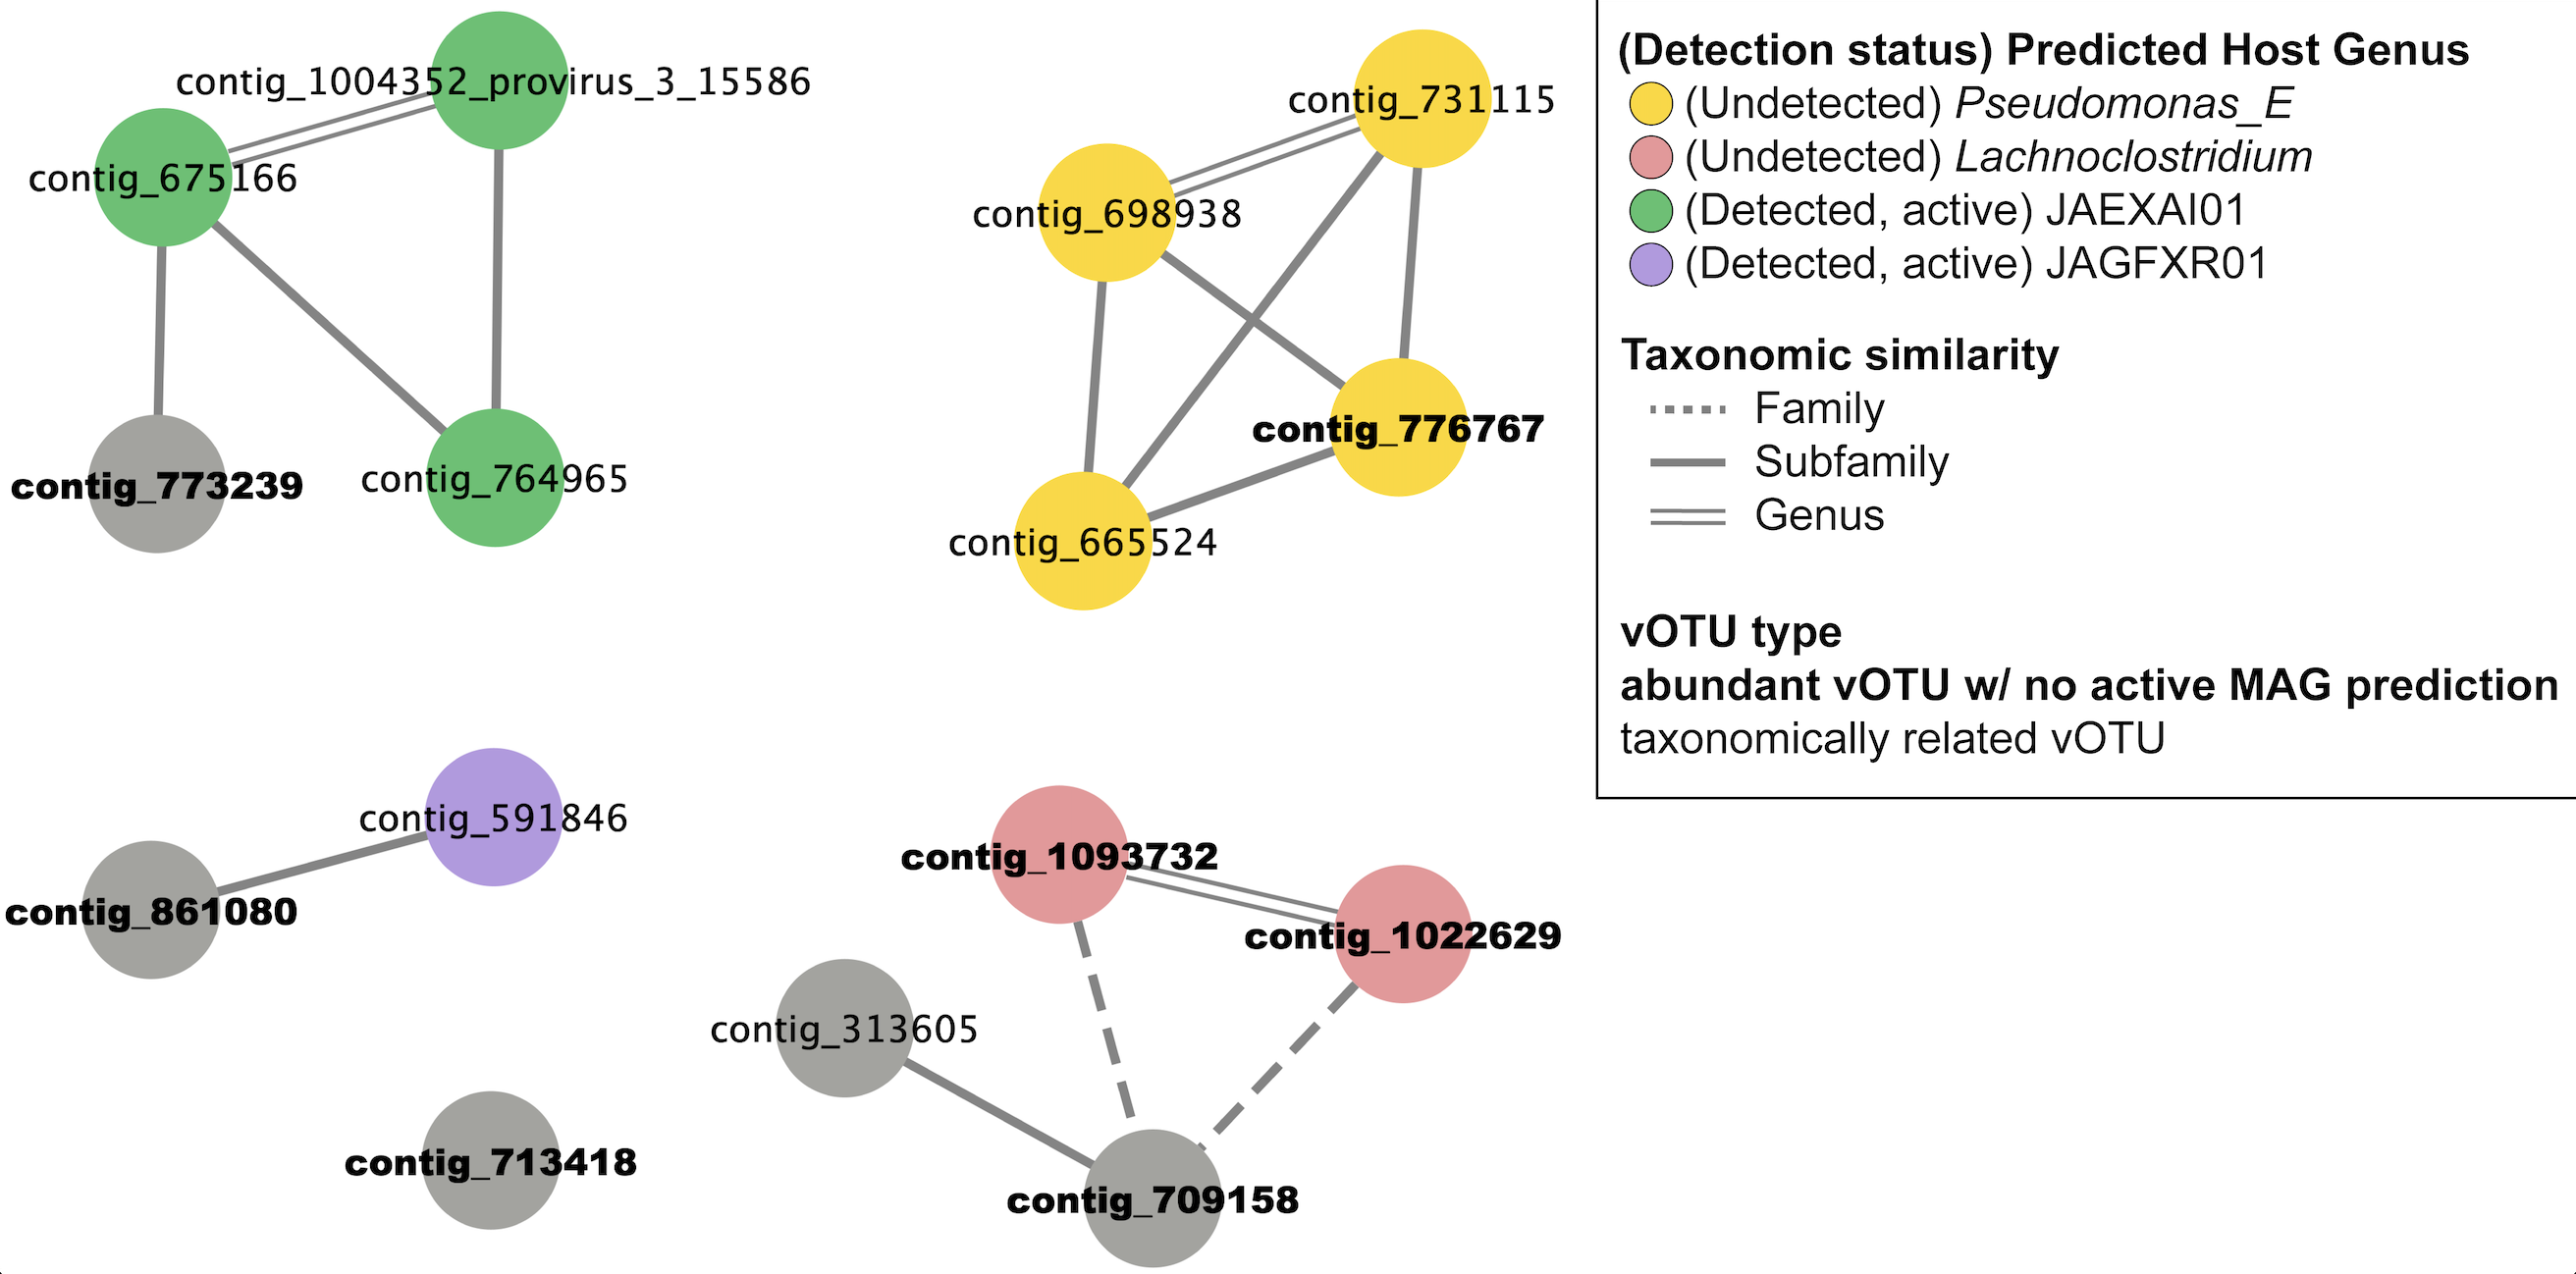

We see that these genus-level predictions are largely consistent within each cluster where a host can be assigned. Based on these relationships, we are making a bold, and potentially incorrect assumption, that these other unassigned vOTUs infect similarly-related hosts.

Regardless, it is more information than we had to go on before, and can use these second-tier predictions to explain more of the signal. Below is a re-colored graph based on these new host assignments for previously unassigned vOTUs:

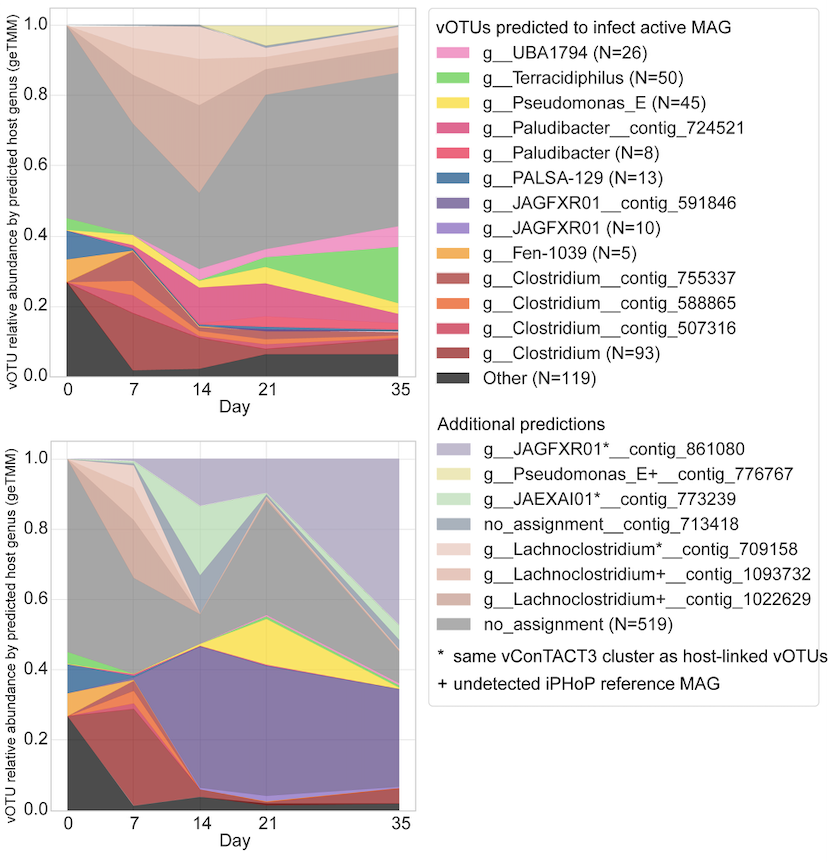

Reflection and critique: A few of these vOTUs that garnered high normalized relative abundance scores were very small viral fragments (looking at you, contig_861080).

What are potential outcomes if we recovered a longer contig of these vOTUs? What would you check to ensure the observed relative abundance is a real biological signal versus a technical artifact?

**\<Your response here\>**

# Part 3: A closer look at the highly active vOTU predicted to infect the key catechin degrader JAGFXR01.

The previous study identified JAGFXR01, an uncultured *Bacillota*, as the most active catechin degrader based on relative expression of genes annotated to produce catechin-degrading enzymes.

Based on our analysis above, a single vOTU predicted to infect JAGFXR01 accounted for at least 40% of relative activity. However, with the data above, we still don't know anything about the virus lifestyle (obligately lytic, temperate, chronic infection?) or what genes were being actively transcribed (could have been mostly temperate phage genes).

Since this is potentially the major finding we want to report in the study, we want to build confidence in ourselves and for others that (1) this is actually a virus contig, and if possible, be able to say (2) what kind of virus it is, (3) what genes are being transcribed, (4) what is the basis of the virus-host prediction and can it be manually verified, and (5) how abundant is it relative to the host its predicted to infect? This requires going back into those datasets we generated with the suite of viromics tools, and now that we know what we're looking for, looking past the summary statistics and pulling out a specific virus contig.

### What kind of virus, and what genes are being transcribed?
To figure out what kind of virus this contig is, we can inspect the genome annotations

In [19]:
# Load the intermediate CSV file

# DRAMv output with additional columns from genomad annotations
# and a concatenated column of all annotations for each gene from each database.
file_name = "contig_591846_annotations.tsv"
path = '/'.join([data_dir, file_name])
df_genes = pd.read_csv(path, sep='\t')
df_genes.head()

,vOTU,length,topology,coordinates,n_genes,genetic_code,virus_score,fdr,n_hallmarks,marker_enrichment,...,vogdb_categories,heme_regulatory_motif_count,virsorter_category,auxiliary_score,is_transposon,amg_flags,annotation_accessions,annotation_description,evalue,concat_annotations
0,contig_591846,40862,No terminal repeats,NaN,63,11,0.9981,0.0018,17,63.3295,...,NaN,0.0,-,5.0,False,F,NaN,NaN,NaN,rpi:Rpic_4896 acriflavin resistance protein;;...
1,contig_591846,40862,No terminal repeats,NaN,63,11,0.9981,0.0018,17,63.3295,...,NaN,0.0,0,4.0,False,F,COG5377,"Phage-related protein, predicted endonuclease",3.893000e-09,bprl:CL2_29940 putative phage-type endonuclea...
2,contig_591846,40862,No terminal repeats,NaN,63,11,0.9981,0.0018,17,63.3295,...,Xu,0.0,1,1.0,False,PF,PF07083,NaN,3.337000e-44,ere:EUBREC_2126 hypothetical protein;YP_00222...
3,contig_591846,40862,No terminal repeats,NaN,63,11,0.9981,0.0018,17,63.3295,...,Xr,0.0,1,1.0,False,VF,PF03837;TIGR01913;COG3723,phage recombination protein Bet,3.745000e-36,cpas:Clopa_4307 phage recombination protein B...
4,contig_591846,40862,No terminal repeats,NaN,63,11,0.9981,0.0018,17,63.3295,...,Xu,0.0,1,1.0,False,F,PF16784,Putative HNHc nuclease,9.788000e-55,amt:Amet_2584 hypothetical protein;;Putative ...


In [20]:
df_genes.columns

Index(['vOTU', 'length', 'topology', 'coordinates', 'n_genes', 'genetic_code',
       'virus_score', 'fdr', 'n_hallmarks', 'marker_enrichment', 'taxonomy',
       'contig_length', 'provirus', 'proviral_length', 'gene_count',
       'viral_genes', 'host_genes', 'checkv_quality', 'miuvig_quality',
       'completeness', 'completeness_method', 'contamination', 'kmer_freq',
       'warnings', 'is_provirus_aggregated', 'Unnamed: 0', 'fasta',
       'gene_position', 'start_position', 'end_position', 'strandedness',
       'rank', 'kegg_genes_id', 'ko_id', 'kegg_hit', 'kegg_RBH',
       'kegg_identity', 'kegg_bitScore', 'kegg_eVal', 'viral_id', 'viral_hit',
       'viral_RBH', 'viral_identity', 'viral_bitScore', 'viral_eVal',
       'peptidase_id', 'peptidase_family', 'peptidase_hit', 'peptidase_RBH',
       'peptidase_identity', 'peptidase_bitScore', 'peptidase_eVal',
       'pfam_hits', 'cazy_ids', 'cazy_hits', 'cazy_subfam_ec', 'cazy_best_hit',
       'vogdb_id', 'vogdb_hits', 'vogdb_categ

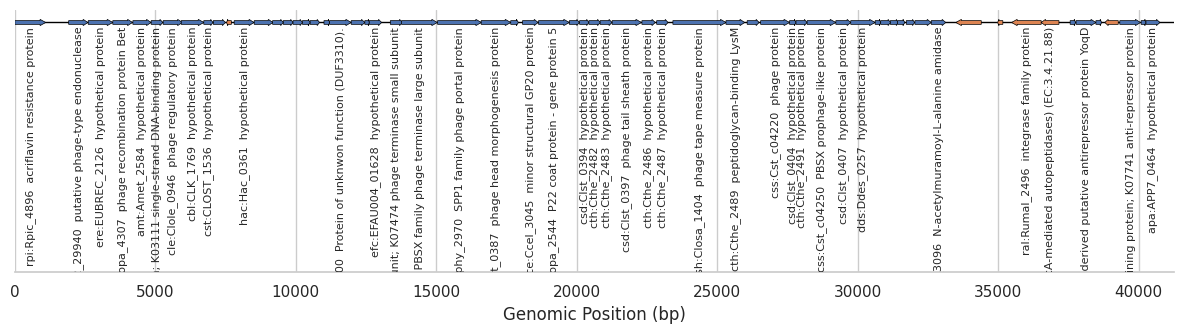

In [21]:

import matplotlib.patches as patches

# --- Choose which functional annotation database to label with ---
# Database options:
# "kegg_hit", "viral_hit", "peptidase_hit", "cazy_best_hit", "vogdb_hits"
# "annotation_description" (genomad)
# "concat_annotations" (all annotations per-gene concatenated into one string)
label_col = "kegg_hit"  #

genome_length = df_genes["end_position"].max() + 500  # Expand buffer slightly

fig, ax = plt.subplots(figsize=(12, 3.5))  # Increased height slightly for vertical labels

for _, row in df_genes.iterrows():
    start, end, strand = row["start_position"], row["end_position"], row["strandedness"]
    length = end - start
    color = "#4C72B0" if strand in ["+", 1] else "#DD8452"
    head_len = min(length * 0.25, 200)

    dx = length if strand in ["+", 1] else -length
    x_start = start if strand in ["+", 1] else end

    # 1. Draw Arrow
    arrow = patches.FancyArrow(
        x_start, 0, dx, 0,
        width=0.3, head_width=0.5, head_length=head_len,
        length_includes_head=True, color=color, ec="black", linewidth=0.5
    )
    ax.add_patch(arrow)

    # 2. Add Label Below (if column exists and value isn't empty/NaN)
    if label_col in row and pd.notna(row[label_col]):
        label_text = str(row[label_col])
        midpoint = start + (length / 2)  # Center text relative to the gene

        ax.text(
            x=midpoint,
            y=-0.35,  # Placed just below the arrow track
            s=label_text,
            rotation=90,
            ha="center",  # Horizontal center aligned with gene midpoint
            va="top",  # Top of the text anchored at y=-0.35 (grows downwards)
            fontsize=8,
            clip_on=True  # Keeps labels within plot bounds
        )

# Baseline genome track
ax.plot([0, genome_length], [0, 0], color="black", linewidth=1, zorder=0)

# Styling
ax.set_xlim(0, genome_length)
ax.set_ylim(-20.0, 1)  # Expanded y-lower limit to give vertical text room to fit
ax.set_yticks([])
ax.set_xlabel("Genomic Position (bp)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

##  The annotations always come out messy, so here's the published version where I synthesized the annotations and removed the database-specific components:

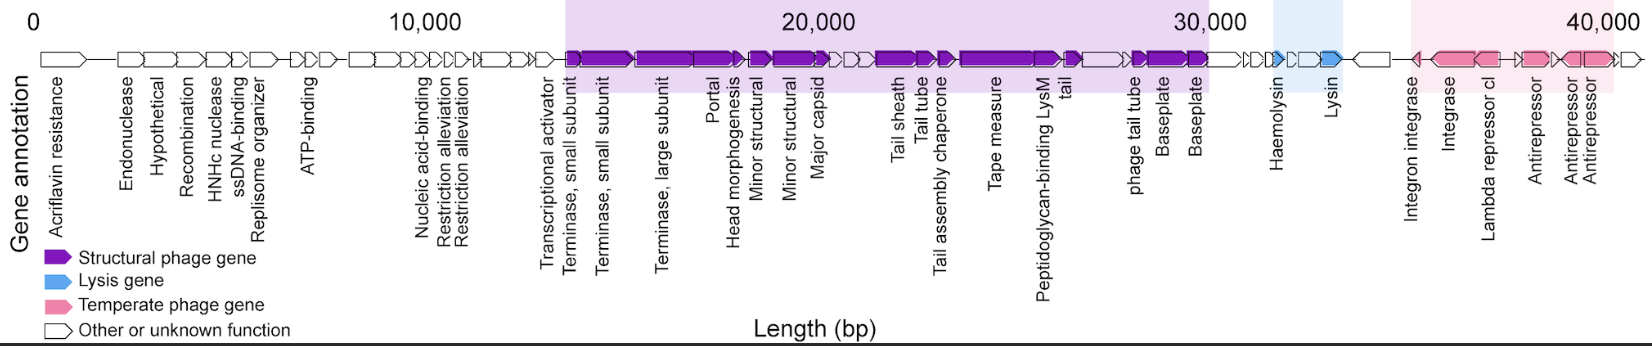

## Reflection:
1. Based on these annotations, what kind of virus do you think this is (i.e., obligately lytic, temperate)?


**\<Type your answer here\>**

2. Find "contig_591846.fna" in the data directory, download it, and blast it against NCBI: https://blast.ncbi.nlm.nih.gov/Blast.cgi. Have we seen similar viruses like this before? If yes, how similar (% identity)?


**\<Type your answer here\>**


# For this next part, we will figure out how active this virus really is, and which parts of the genome are most highly expressed.

To see which regions of the genome were most highly expressed, we will be looking at results from samtools m-pileup, which counts the number of reads that covered each base position in each sample.

We will combine it with the gene plot above to see which genes were most highly expressed, and infer what stage(s) of infection viruses within this vOTU are in.

In [22]:


# --- 1. Load and Process Data ---

# Ridgeline Data
pileup_file = os.path.join(data_dir, "combined_pileup.csv")
pileup_data = pd.read_csv(pileup_file)
pileup_data["sample"] = pileup_data["sample"].str.replace("_90FILTERED", "", regex=False)

metadata_file = os.path.join(data_dir, "sample_metadata.csv")
metadata = pd.read_csv(metadata_file)
metadata["sample"] = metadata["Sample"]

pileup_data = pd.merge(pileup_data, metadata, on="sample", how="left")
pileup_data["sample"] = pileup_data["treatment_day_replicate"]

# Filter for samples starting with 'catechin' (case-insensitive)
pileup_data = pileup_data[pileup_data["sample"].str.contains(r"^catechin", case=False, na=False)].copy()

# BLAST Alignment Data
blast_file = os.path.join(data_dir, "4B_contig_591846_STM_0716_E_M_E034_A_bin.10_blastn.txt")
blast_headers = ["qacc", "sacc", "pident", "length", "mismatch", "gapopen",
                 "qstart", "qend", "sstart", "send", "evalue", "bitscore"]
blast_data = pd.read_csv(blast_file, sep="\t", comment="#", names=blast_headers)

# Genome Data Paths
fasta_path = os.path.join(data_dir, "contig_591846.fna")
gff_path = os.path.join(data_dir, "contig_591846.gff")

# Determine Genome Length from FASTA (Standard Python line-by-line)
genome_length = 0
with open(fasta_path) as handle:
    for line in handle:
        if not line.startswith(">"):
            genome_length += len(line.strip())

# Parse GFF Features (Standard Python text splitting)
features = []
with open(gff_path) as handle:
    for line in handle:
        if line.startswith("#") or not line.strip():
            continue
        parts = line.strip().split("\t")
        if len(parts) >= 9 and parts[2] in ["gene", "CDS"]:
            start = int(parts[3])
            end = int(parts[4])
            strand = 1 if parts[6] == "+" else -1
            color = "skyblue" if strand == 1 else "salmon"

            # Extract name from attributes if available
            name = ""
            for attr in parts[8].split(";"):
                if attr.startswith("Name="):
                    name = attr.split("=")[1]
                    break

            features.append({
                "start": start,
                "end": end,
                "strand": strand,
                "color": color,
                "label": name
            })


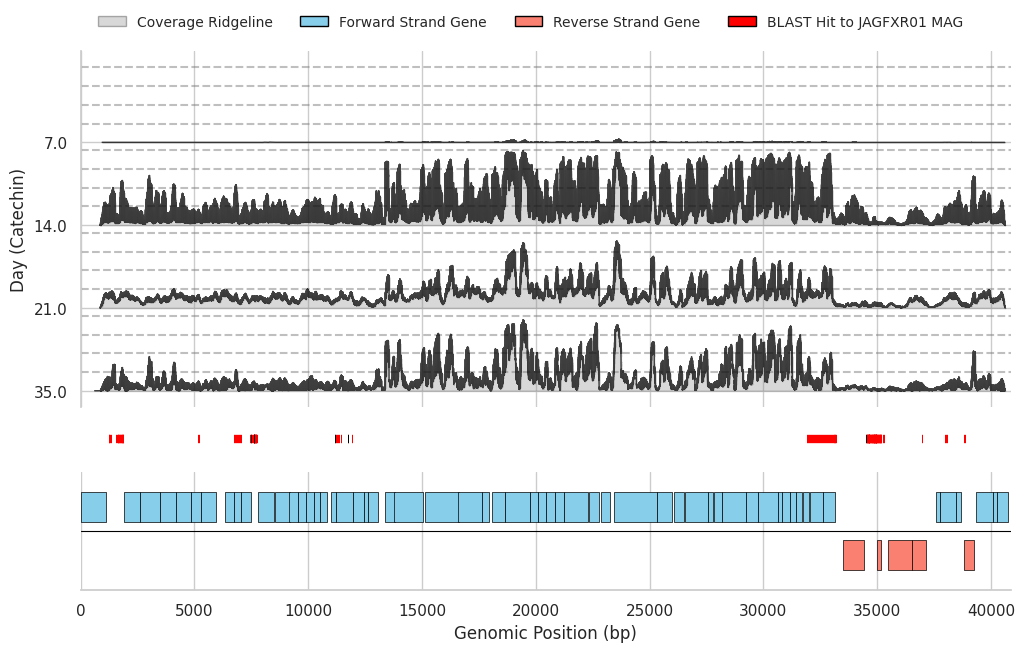

In [23]:
# --- 2. Create Plots with Subplots ---

fig, (ax_top, ax_mid, ax_bot) = plt.subplots(
    3, 1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 0.4, 1]}
)
plt.subplots_adjust(hspace=0.05)

# --- A. Ridgeline Plot (Top) ---
days = sorted(pileup_data["day"].unique(), key=int)
max_cov = pileup_data["coverage"].max()
grid_values = [2000, 4000, 6000, 8000]

for idx, day_val in enumerate(reversed(days)):
    y_base = idx
    day_df = pileup_data[pileup_data["day"] == day_val].sort_values("position")

    # Custom Gridlines
    for gval in grid_values:
        rel_height = (gval / max_cov) * 0.9
        y_pos = y_base + rel_height
        ax_top.plot([0, genome_length], [y_pos, y_pos], color="gray", linestyle="--", alpha=0.5, zorder=1)

    # Ridgeline Fill and Border
    x = day_df["position"].values
    y_scaled = y_base + (day_df["coverage"].values / max_cov) * 0.9

    ax_top.fill_between(x, y_base, y_scaled, color="grey", alpha=0.3, zorder=2)
    ax_top.plot(x, y_scaled, color="black", alpha=0.7, linewidth=1, zorder=3)

ax_top.set_yticks(range(len(days)))
ax_top.set_yticklabels(reversed(days))
ax_top.set_ylabel("Day (Catechin)")
ax_top.set_xlim(0, genome_length)
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_top.spines['bottom'].set_visible(False)
ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# --- B. BLAST Alignment Plot (Middle) ---
for _, row in blast_data.iterrows():
    qstart, qend = min(row["qstart"], row["qend"]), max(row["qstart"], row["qend"])
    ax_mid.hlines(y=0, xmin=qstart, xmax=qend, colors="red", linewidth=6)
    ax_mid.hlines(y=0, xmin=qstart, xmax=qstart + 10, colors="black", linewidth=6)

ax_mid.set_ylim(-0.5, 0.5)
ax_mid.set_ylabel("Host Align", rotation=90, labelpad=15, va="center")
ax_mid.axis("off")

# --- C. Genome Plot (Bottom - Using standard Matplotlib) ---
for feat in features:
    start = feat["start"]
    length = feat["end"] - start
    # Forward strand features drawn above center line, reverse below
    y_pos = 0.4 if feat["strand"] == 1 else -0.4

    ax_bot.broken_barh([(start, length)], (y_pos - 0.25, 0.5),
                       facecolors=feat["color"], edgecolors="black", linewidth=0.5)

ax_bot.set_ylim(-1, 1)
ax_bot.axhline(0, color="black", linewidth=0.8, linestyle="-")
ax_bot.set_xlabel("Genomic Position (bp)")
ax_bot.spines['top'].set_visible(False)
ax_bot.spines['right'].set_visible(False)
ax_bot.spines['left'].set_visible(False)
ax_bot.set_yticks([])

# --- D. Custom Figure-Wide Legend ---
legend_elements = [
    Patch(facecolor='grey', alpha=0.3, edgecolor='black', label='Coverage Ridgeline'),
    Patch(facecolor='skyblue', edgecolor='black', label='Forward Strand Gene'),
    Patch(facecolor='salmon', edgecolor='black', label='Reverse Strand Gene'),
    Patch (facecolor='red', edgecolor='black', label='BLAST Hit to JAGFXR01 MAG')
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.95),
    ncol=4,
    frameon=False,
    fontsize=10
)

plt.show()

As you can see from the plot above, there are certain regions of the genome that were more highly expressed. Here is the cleaned up, published version of the plot (generated in R) combining the annotations and coverage:

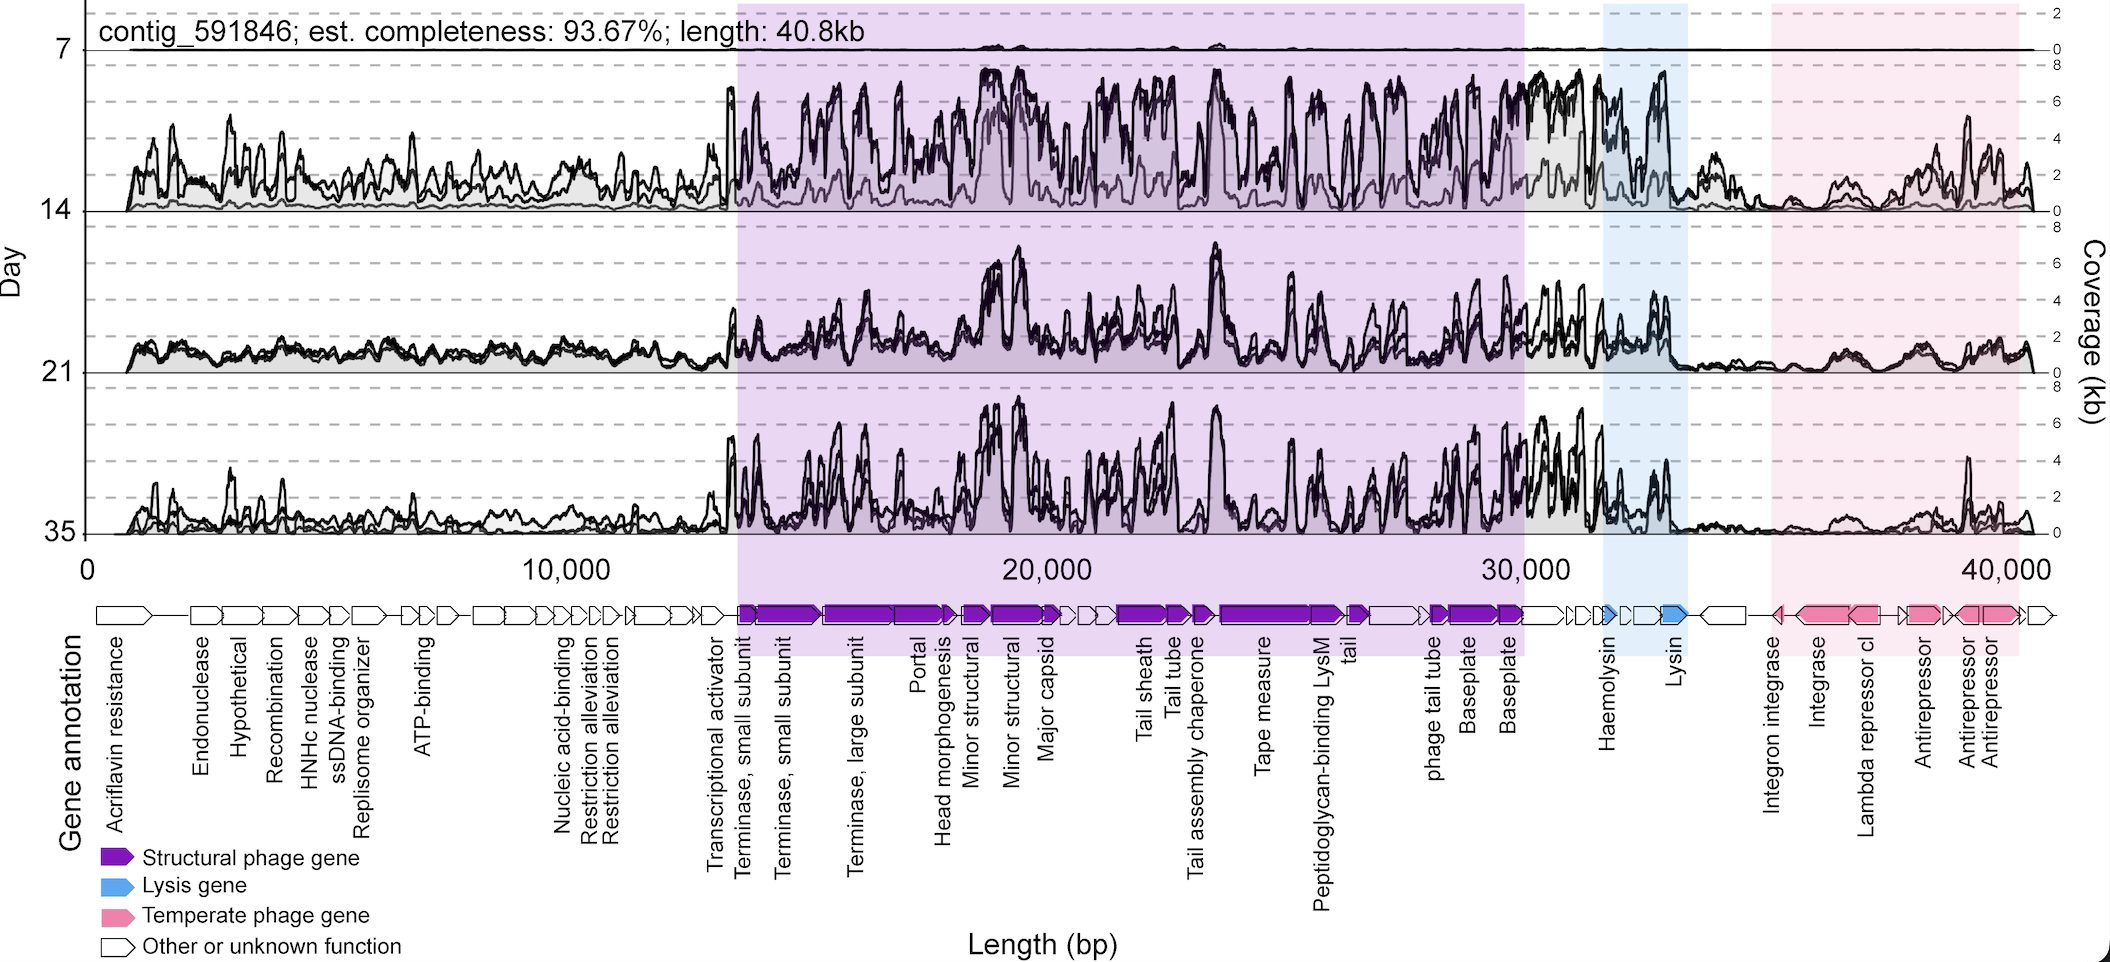

## Reflection

1. Based on the plot above, which regions of the genome are the most highly expressed?


**\<Type your answer here\>**

2. What can you infer is happening in the system based on these results? Unless you are a phage biologist, you may need to look up what some of these genes do!


**\<Type your answer here\>**

3. What do you make of the BLAST hits (red marks in the generated plot)? Are you convinced this vOTU infects JAGFXR01 (the primary catechin degrader)?


**\<Type your answer here\>**

## Ending notes

Thank you for making it to the end! I hope you got a taste of what's possible with the latest viromics tools. This hands-on example was based on previous work published in PLOS Biology: https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.3003925

If there is something you wanted to learn at this workshop but didn't get the chance, please talk to our instructors and they would be happy to help or point you to the right resource.

This is our first time doing hands-on examples, so if you have any feedback for us, please either open a github issue or email me at riddell.26@osu.edu!